# 5 · ¿Más señal? Features agronómicas y satelitales

**Hipótesis:** si el clima mensual no ve ~2/3 de las anomalías (nb. 4), quizás
otras fuentes sí: features **agronómicas** de la ventana crítica del cultivo, el
**verdor de la planta** (NDVI-AVHRR, 1981+, vía Google Earth Engine) y el **estado del
suelo + heladas** (ERA5-Land). Si una plaga arrasa un lote, el clima no lo registra —
pero el NDVI debería.

Cada adición se evalúa con el flag correspondiente del pipeline (`use_agro_features`,
`use_ndvi`, `use_era5_features`), mismo protocolo, sobre el VAE y el IForest.

In [1]:
import os, explib
os.chdir(explib.ROOT)          # rutas relativas (data/, configs/, runs/) funcionan
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
plt.rcParams['figure.dpi'] = 110

## 5.1 · Features agronómicas (ventana crítica + balance hídrico)
Precipitación, estrés térmico y balance hídrico de Hargreaves en la ventana crítica
del cultivo (Dic–Feb soja / Nov–Ene maíz): conocimiento de dominio destilado en
~4 features.

In [2]:
explib.show(explib.compare_table([
    ("iforest_v2_mf03_n200","IForest base"), ("iforest_v2_agro","IForest + agro"),
    ("vae_v4_reconprob_lat16","VAE base"), ("vae_v4_agro","VAE + agro")], "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,IForest base,0.511±0.031,0.688±0.030,0.390±0.034,0.470±0.035,0.266±0.023
1,IForest + agro,0.549±0.023,0.729±0.020,0.403±0.015,0.513±0.030,0.274±0.011
2,VAE base,0.559±0.035,0.719±0.027,0.486±0.026,0.518±0.035,0.279±0.018
3,VAE + agro,0.480±0.082,0.661±0.056,0.344±0.105,0.436±0.068,0.235±0.071


## 5.2 · NDVI-AVHRR (verdor, 1981+)
NDVI mensual por departamento desde 1981 (AVHRR), mergeado por
`[provincia, departamento, campaña]` — historia completa, sin recortar el train.
*(El NDVI de MODIS se descartó de plano: solo existe desde 2002 y recortar la historia
de train cuesta más de lo que el NDVI aporta.)*

In [3]:
explib.show(explib.compare_table([
    ("vae_seedens_v1","VAE seed-ens base"), ("vae_seedens_v1_ndvilargo","VAE seed-ens + NDVI"),
    ("iforest_v2_mf03_n200","IForest base"), ("iforest_v2_ndvilargo","IForest + NDVI")], "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,VAE seed-ens base,0.592±0.010,0.738±0.005,0.432±0.003,0.558±0.013,0.297±0.002
1,VAE seed-ens + NDVI,0.561±0.011,0.713±0.011,0.487±0.010,0.499±0.015,0.292±0.005
2,IForest base,0.511±0.031,0.688±0.030,0.390±0.034,0.470±0.035,0.266±0.023
3,IForest + NDVI,0.503±0.026,0.654±0.022,0.431±0.017,0.447±0.022,0.259±0.013


## 5.3 · ERA5-Land: humedad de suelo + heladas
Cuatro features por (departamento, campaña): humedad de suelo en siembra y en el
invierno previo (inercia hídrica), días de helada y heladas tardías.

In [4]:
explib.show(explib.compare_table([
    ("vae_seedens_v1","VAE seed-ens base"), ("vae_seedens_v1_era5","VAE seed-ens + ERA5"),
    ("iforest_v2_mf03_n200","IForest base"), ("iforest_v2_era5","IForest + ERA5")], "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,VAE seed-ens base,0.592±0.010,0.738±0.005,0.432±0.003,0.558±0.013,0.297±0.002
1,VAE seed-ens + ERA5,0.580±0.002,0.727±0.004,0.515±0.006,0.538±0.000,0.297±0.002
2,IForest base,0.511±0.031,0.688±0.030,0.390±0.034,0.470±0.035,0.266±0.023
3,IForest + ERA5,0.542±0.029,0.719±0.022,0.455±0.008,0.498±0.036,0.282±0.012


### Resumen visual: efecto de cada adición sobre cada modelo

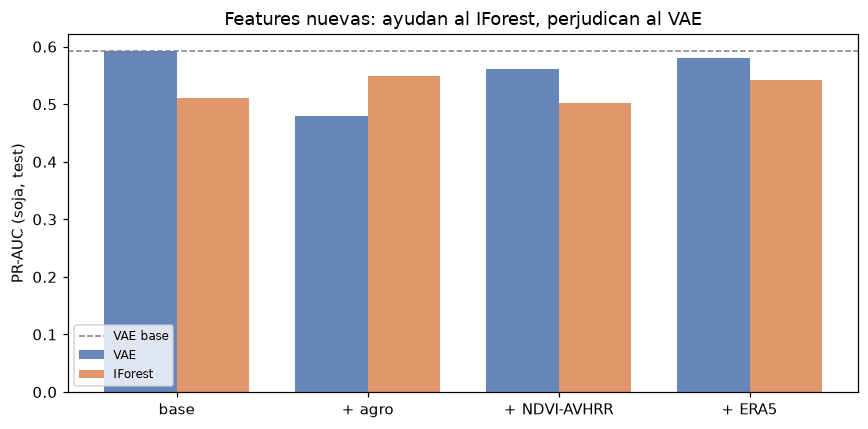

(la fila 'agro' usa el VAE single — la ablación agro se corrió sobre ese modelo)


In [5]:
pares = [("base", "vae_seedens_v1", "iforest_v2_mf03_n200"),
         ("+ agro", "vae_v4_agro", "iforest_v2_agro"),
         ("+ NDVI-AVHRR", "vae_seedens_v1_ndvilargo", "iforest_v2_ndvilargo"),
         ("+ ERA5", "vae_seedens_v1_era5", "iforest_v2_era5")]
def pr(name):
    rid = explib.latest_run(name, "soja")
    s = explib.load_run(rid).summary
    return s.get("test_pr_auc_mean", s.get("test_pr_auc"))
labs = [p[0] for p in pares]
vae_v = [pr(p[1]) for p in pares]; ifo_v = [pr(p[2]) for p in pares]
x = np.arange(len(labs)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, vae_v, w, label="VAE", color="#4C72B0", alpha=0.85)
ax.bar(x + w/2, ifo_v, w, label="IForest", color="#DD8452", alpha=0.85)
ax.axhline(pr("vae_seedens_v1"), ls="--", color="gray", lw=1, label="VAE base")
ax.set_xticks(x); ax.set_xticklabels(labs)
ax.set_ylabel("PR-AUC (soja, test)"); ax.legend(fontsize=8)
ax.set_title("Features nuevas: ayudan al IForest, perjudican al VAE")
plt.tight_layout(); plt.show()
print("(la fila 'agro' usa el VAE single — la ablación agro se corrió sobre ese modelo)")

**Conclusiones del notebook:**
- **Asimetría consistente**: las features extra ayudan (modestamente) al IForest — que
  submuestrea columnas y tolera agregados — y **perjudican al VAE**, que debe
  reconstruir TODAS las features: cada columna nueva diluye el `recon_prob` y sube la
  varianza.
- **Ninguna combinación supera al VAE base** (0.592): el mejor "aumentado" es
  IForest+ERA5, y queda abajo.
- El resultado **confirma el techo del nb. 4**: si ni el verdor de la planta marca esas
  anomalías, no son fallas biofísicas observables por satélite. Mejorar requiere otra
  clase de datos (sanidad, granizo, manejo), no más features climático-satelitales.

**Próximo notebook:** la última vara — los métodos modernos de deep anomaly detection —
y el cierre.